In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as brn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv('Quantum_Error_Prediction_Data_v4.csv')

In [4]:
df.head()

,circuit_id,device_family,device_version,qubit_count,gate_depth,gate_type,cnot_gate_count,single_qubit_gate_count,swap_gate_count,measurement_count,...,shots,bitstring,ideal_bitstring,fidelity,depth_per_qubit,t2_t1_ratio,gate_density,noise_score,error_detected,error_type
0,QC000000,Osprey,v4,56,221,CZ,68,153,12,56,...,2048,10011100,1111010,0.709430,3.946429,0.744021,0.307692,1.000000,Yes,readout
1,QC000001,Condor,v4,86,100,H,31,69,0,86,...,4096,1,10000101,0.752946,1.162791,0.757861,0.310000,0.618937,Yes,amplitude_damping
2,QC000002,Heron,v4,120,654,Z,194,460,11,120,...,1024,10011110,10101,0.704178,5.450000,0.770632,0.296636,1.000000,Yes,leakage
3,QC000003,Eagle,v4,78,51,X,8,43,14,78,...,1024,110001,10101001,0.780763,0.653846,0.818678,0.156863,0.453507,Yes,readout
4,QC000004,Osprey,v4,46,272,RZ,45,227,0,46,...,8192,11001111,10011011,0.652747,5.913043,0.715956,0.165441,1.000000,Yes,leakage


In [5]:
df.tail()

,circuit_id,device_family,device_version,qubit_count,gate_depth,gate_type,cnot_gate_count,single_qubit_gate_count,swap_gate_count,measurement_count,...,shots,bitstring,ideal_bitstring,fidelity,depth_per_qubit,t2_t1_ratio,gate_density,noise_score,error_detected,error_type
99995,QC099995,Hummingbird,v4,105,766,RX,42,724,12,105,...,8192,100001,10111001,0.867065,7.295238,0.950000,0.054830,1.000000,Yes,readout
99996,QC099996,Eagle,v4,54,109,CCX,31,78,7,54,...,1024,10011011,11111110,0.689931,2.018519,0.718367,0.284404,1.000000,Yes,readout
99997,QC099997,Condor,v4,126,367,H,81,286,3,126,...,1024,1111010,10010011,0.760892,2.912698,0.816553,0.220708,0.804563,Yes,amplitude_damping
99998,QC099998,Eagle,v4,52,325,RX,62,263,13,52,...,8192,11001101,10000110,0.835465,6.250000,0.888251,0.190769,0.999481,Yes,readout
99999,QC099999,Heron,v4,61,528,H,208,320,7,61,...,8192,10011001,10000101,0.759603,8.655738,0.792675,0.393939,1.000000,Yes,readout


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   circuit_id               100000 non-null  object 
 1   device_family            100000 non-null  object 
 2   device_version           100000 non-null  object 
 3   qubit_count              100000 non-null  int64  
 4   gate_depth               100000 non-null  int64  
 5   gate_type                100000 non-null  object 
 6   cnot_gate_count          100000 non-null  int64  
 7   single_qubit_gate_count  100000 non-null  int64  
 8   swap_gate_count          100000 non-null  int64  
 9   measurement_count        100000 non-null  int64  
 10  gate_fidelity            100000 non-null  float64
 11  readout_fidelity         100000 non-null  float64
 12  error_rate_gate          100000 non-null  float64
 13  readout_error            100000 non-null  float64
 14  t1_ti

In [7]:
df.describe()

,qubit_count,gate_depth,cnot_gate_count,single_qubit_gate_count,swap_gate_count,measurement_count,gate_fidelity,readout_fidelity,error_rate_gate,readout_error,...,crosstalk_level,temperature_mK,shots,bitstring,ideal_bitstring,fidelity,depth_per_qubit,t2_t1_ratio,gate_density,noise_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,1.000000e+05,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,64.484680,410.407770,91.830580,318.577190,7.515950,64.484680,0.992974,0.972391,0.007026,0.027609,...,4.994628e-02,13.996493,3833.886720,5.540237e+06,5.549735e+06,0.736728,14.553090,0.779987,0.223291,0.934837
std,36.388977,225.362299,79.297739,185.366454,4.606997,36.388977,0.004034,0.015825,0.004034,0.015825,...,2.881330e-02,2.309035,2744.450135,5.026117e+06,5.023459e+06,0.102470,30.672423,0.108473,0.131002,0.150363
min,2.000000,20.000000,0.000000,11.000000,0.000000,2.000000,0.986000,0.945001,0.000050,0.000201,...,1.596270e-07,10.000057,1024.000000,0.000000e+00,0.000000e+00,0.500000,0.158730,0.284513,0.000000,0.000000
25%,33.000000,216.000000,26.000000,163.000000,4.000000,33.000000,0.989487,0.958693,0.003531,0.013912,...,2.507425e-02,11.996354,2048.000000,1.111110e+05,1.111110e+05,0.666525,3.333333,0.708720,0.109589,1.000000
50%,65.000000,411.000000,70.000000,309.000000,8.000000,65.000000,0.992969,0.972407,0.007031,0.027593,...,4.974334e-02,13.996408,2048.000000,1.111111e+06,1.111111e+06,0.735992,6.355769,0.780601,0.223468,1.000000
75%,96.000000,606.000000,140.000000,457.000000,12.000000,96.000000,0.996469,0.986088,0.010513,0.041307,...,7.481028e-02,15.992467,4096.000000,1.011111e+07,1.011111e+07,0.811664,12.423857,0.858133,0.336667,1.000000
max,127.000000,800.000000,360.000000,798.000000,15.000000,127.000000,0.999950,0.999799,0.014000,0.054999,...,9.999960e-02,17.999995,8192.000000,1.111111e+07,1.111111e+07,0.948631,400.000000,0.950000,0.450000,1.000000


In [8]:
df.isnull().sum()

circuit_id                 0
device_family              0
device_version             0
qubit_count                0
gate_depth                 0
gate_type                  0
cnot_gate_count            0
single_qubit_gate_count    0
swap_gate_count            0
measurement_count          0
gate_fidelity              0
readout_fidelity           0
error_rate_gate            0
readout_error              0
t1_time_us                 0
t2_time_us                 0
gate_duration_ns           0
execution_time_us          0
idle_time_us               0
calibration_age_hr         0
qubit_connectivity         0
crosstalk_level            0
temperature_mK             0
shots                      0
bitstring                  0
ideal_bitstring            0
fidelity                   0
depth_per_qubit            0
t2_t1_ratio                0
gate_density               0
noise_score                0
error_detected             0
error_type                 0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

<function matplotlib.pyplot.show(close=None, block=None)>

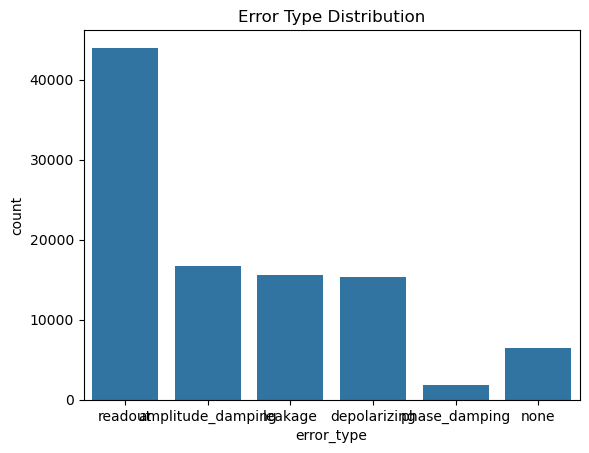

In [10]:
# target distribution
brn.countplot(x='error_type',data=df)
plt.title('Error Type Distribution')
plt.show

# result
# shows severe class imbalence, readout error type is way more than other types
# what to do
# while trainig the model use class weight balance 

<Axes: >

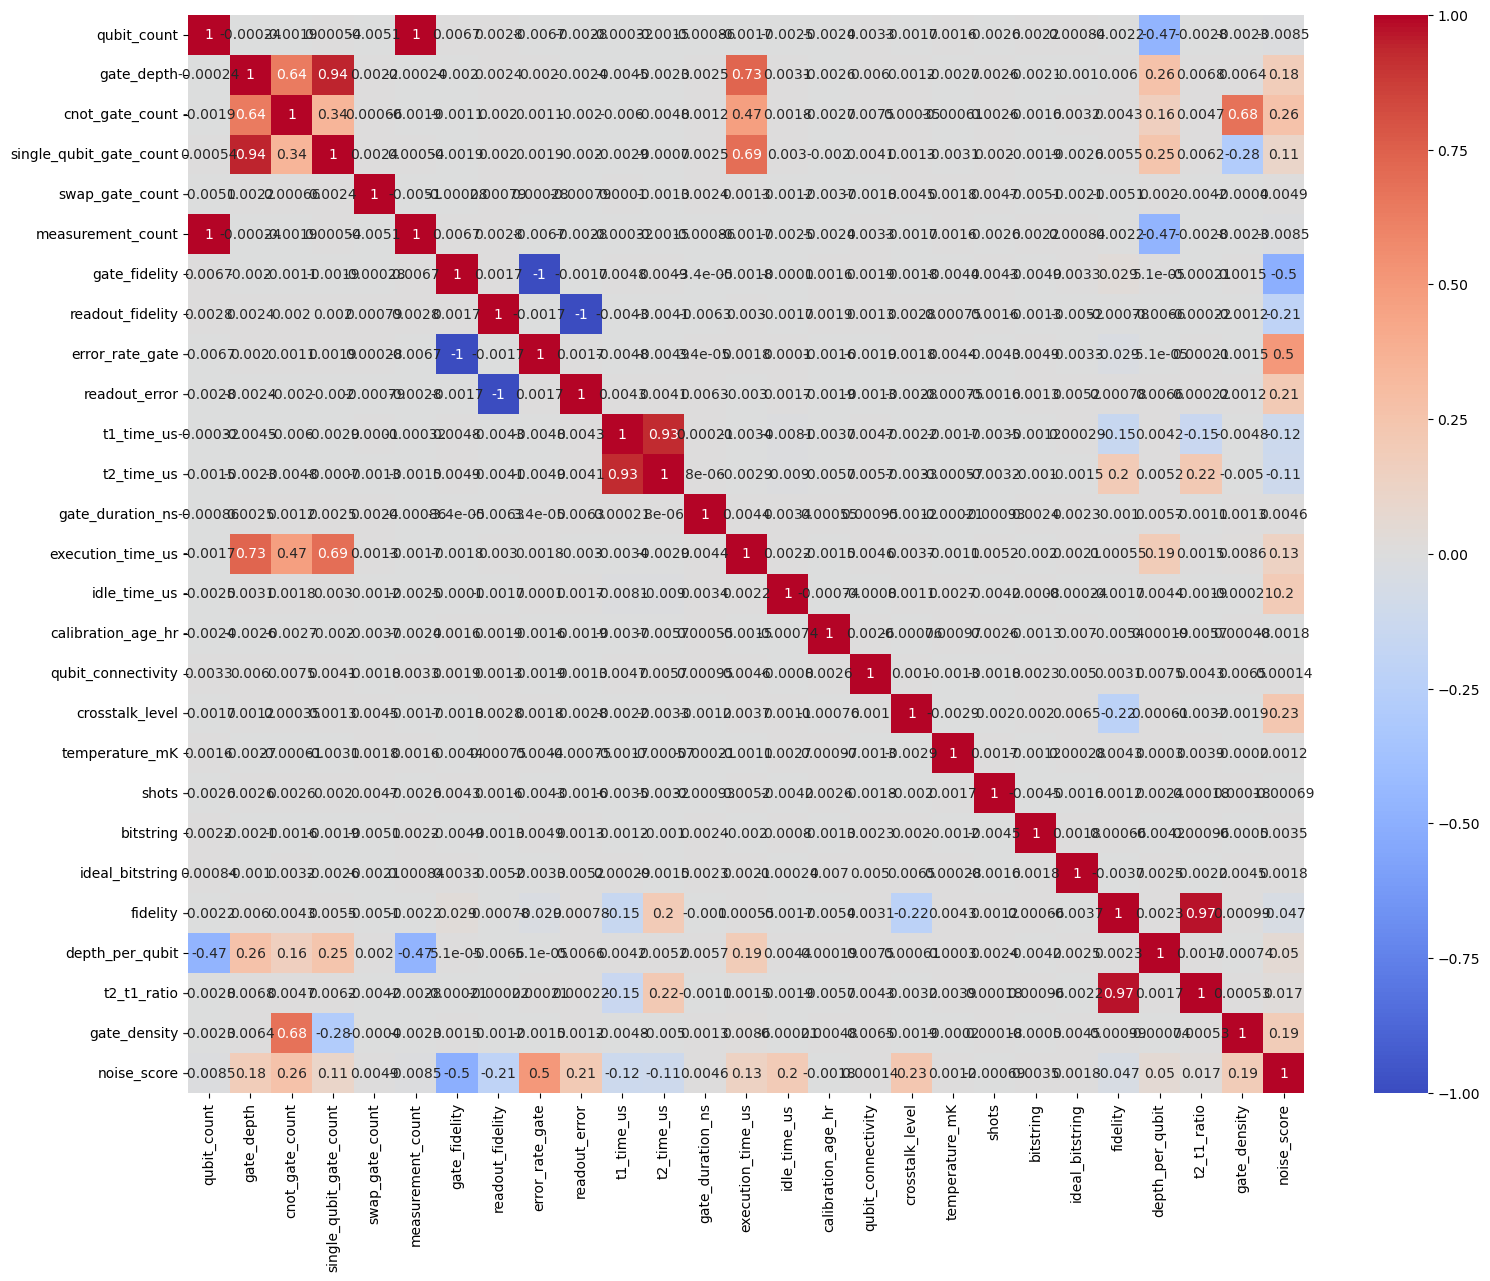

In [11]:
plt.figure(figsize=(18,14))

brn.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')


<function matplotlib.pyplot.show(close=None, block=None)>

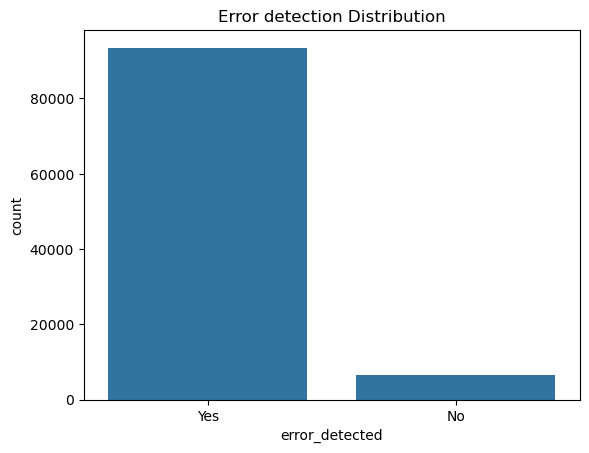

In [12]:
# error detection distribution
brn.countplot(x='error_detected',data=df)
plt.title('Error detection Distribution')
plt.show

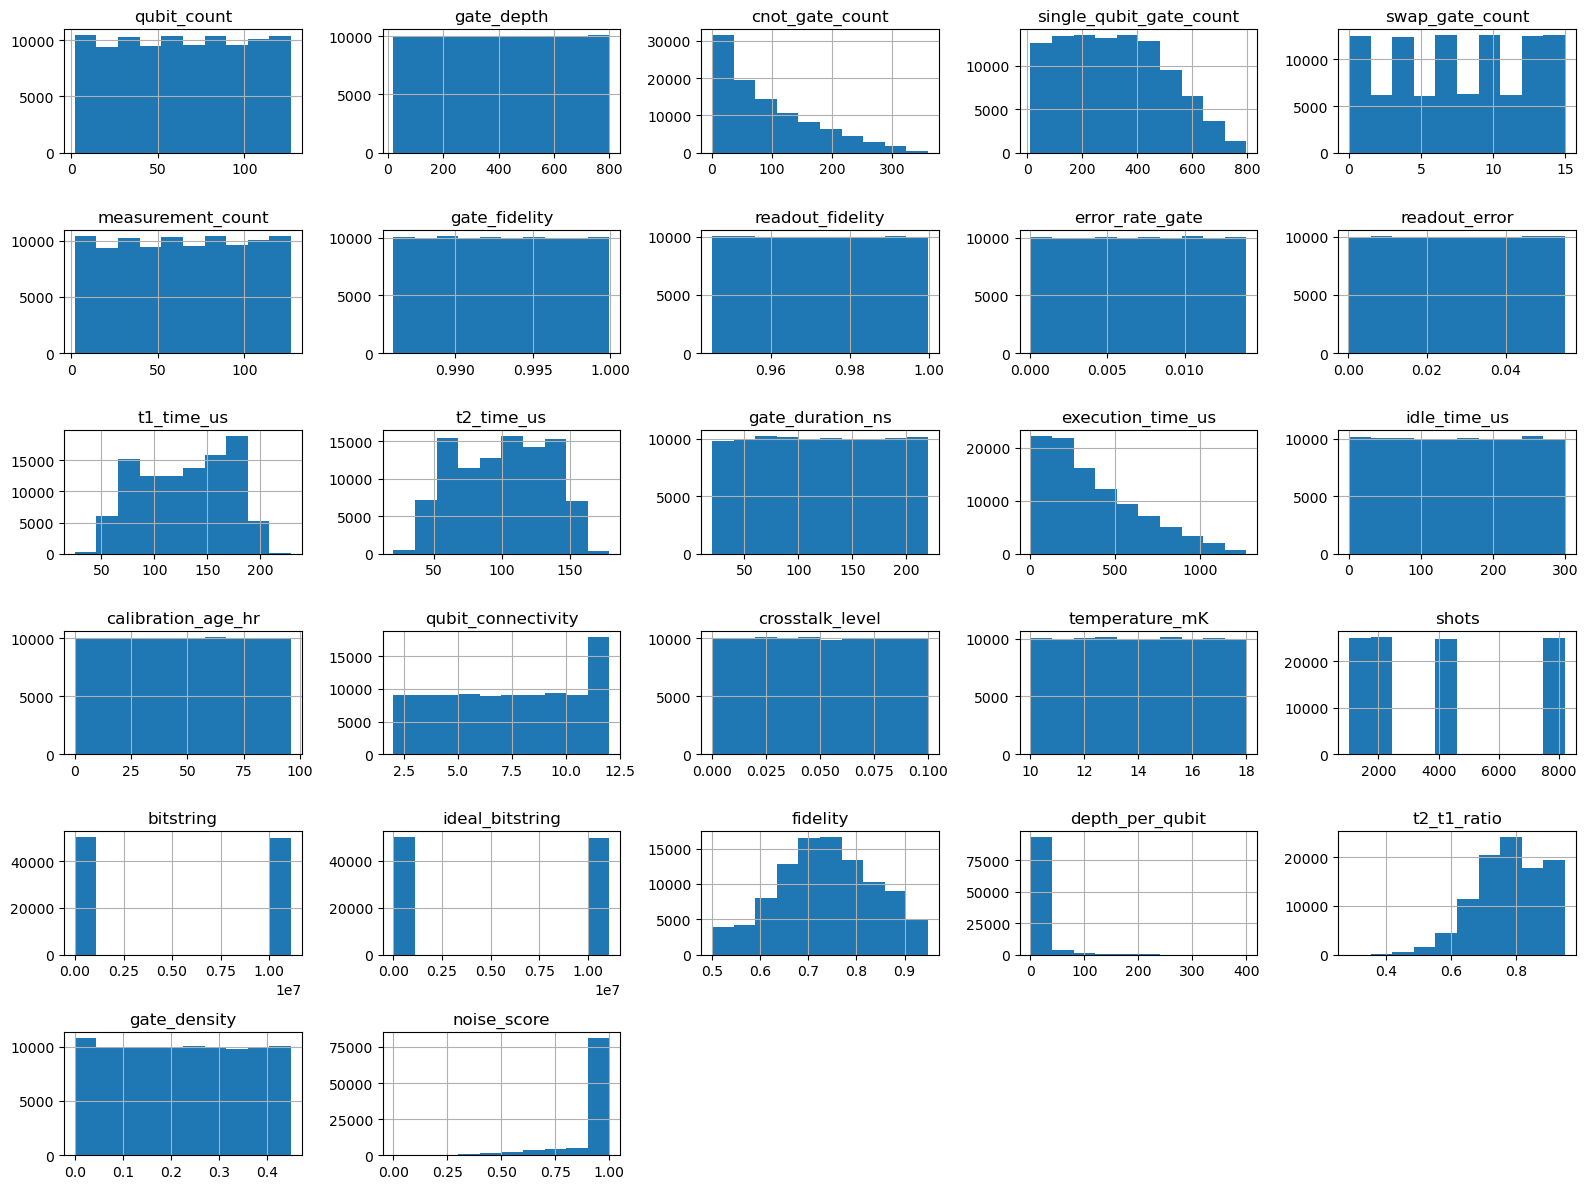

In [13]:
num_col=df.select_dtypes(include=['int64','float64']).columns
df[num_col].hist(figsize=(16,12))
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15228\1060857386.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5,2))


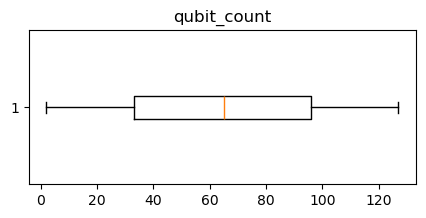

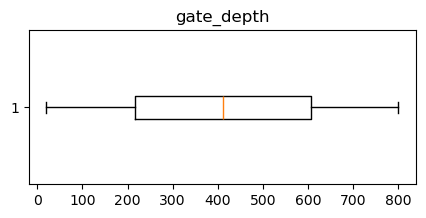

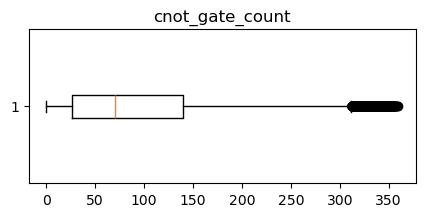

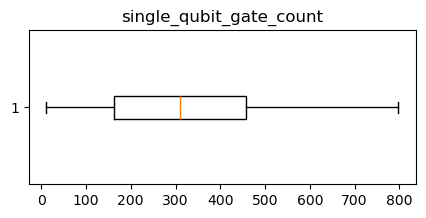

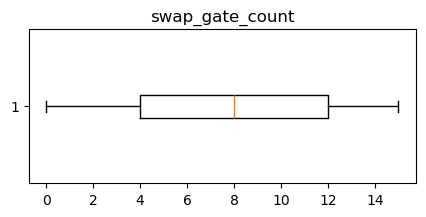

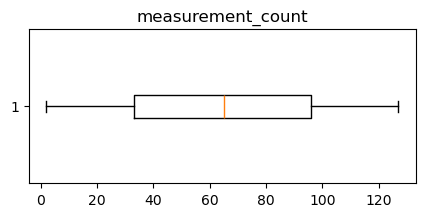

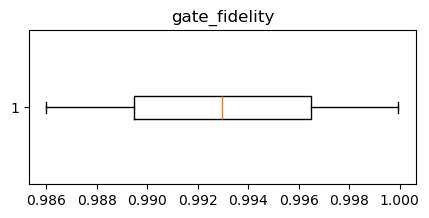

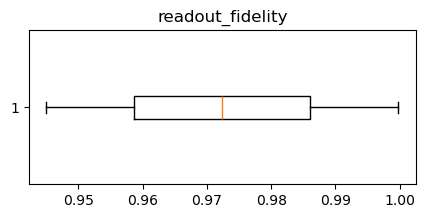

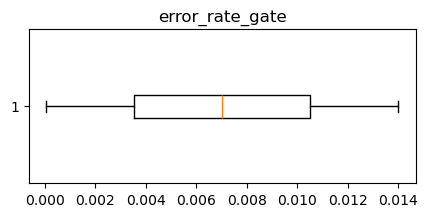

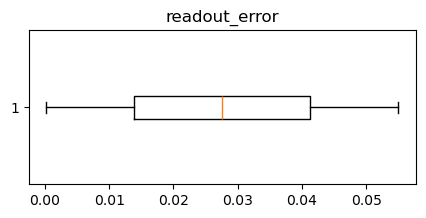

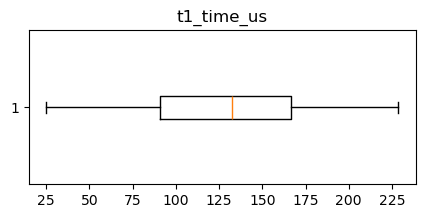

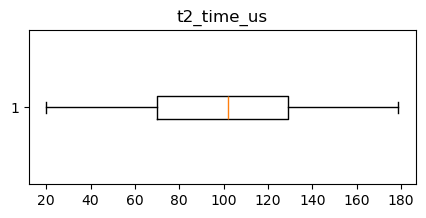

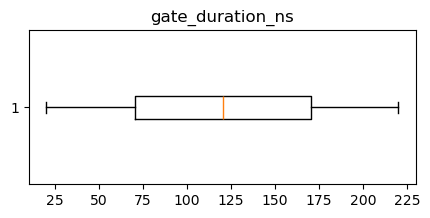

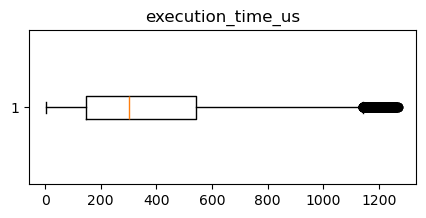

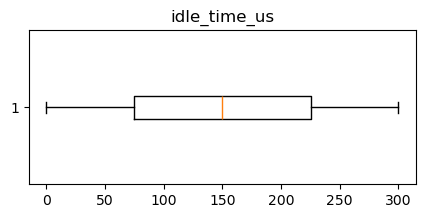

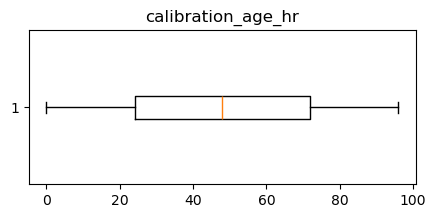

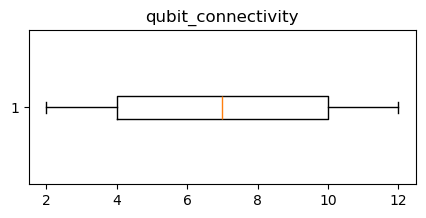

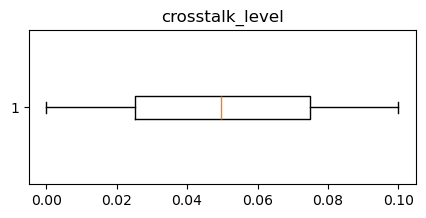

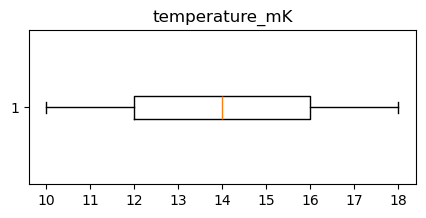

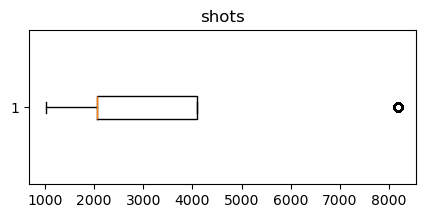

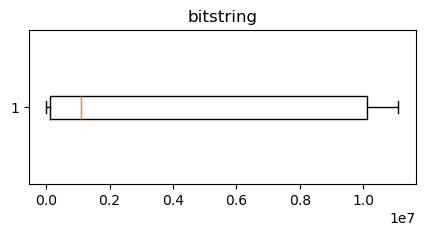

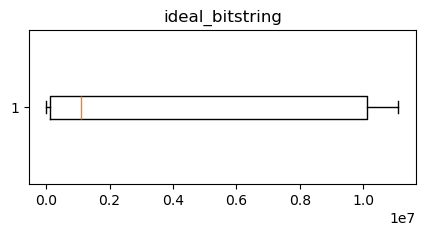

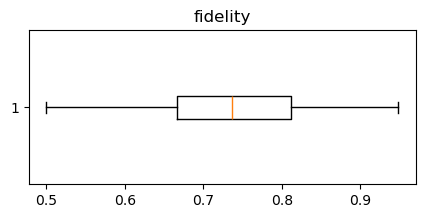

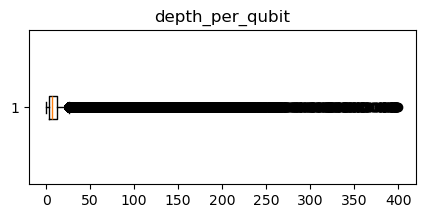

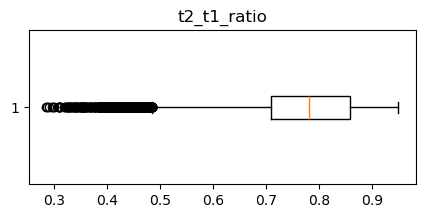

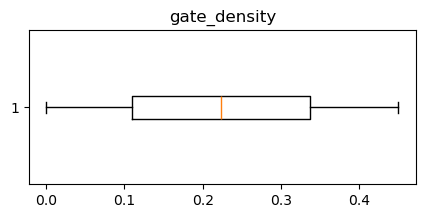

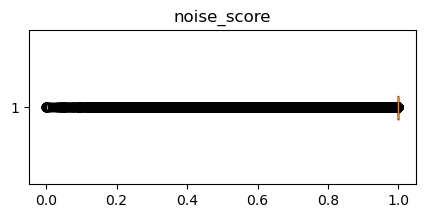

In [14]:
for col in num_col:
    plt.figure(figsize=(5,2))
    plt.boxplot(df[col],vert=False)
    plt.title(col)
    plt.show

<Axes: xlabel='device_family'>

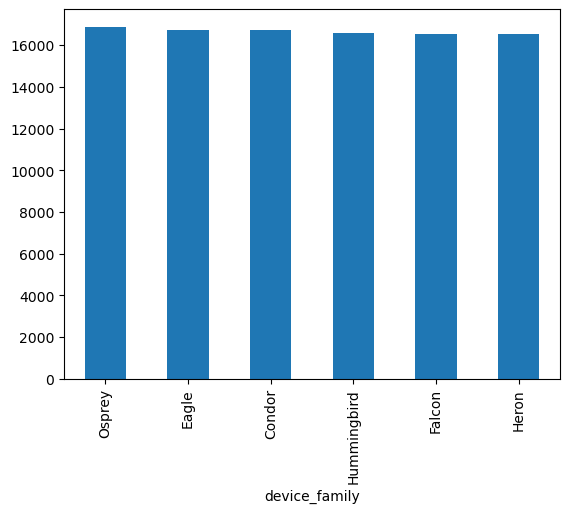

In [15]:
df['device_family'].value_counts().plot(kind='bar')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   circuit_id               100000 non-null  object 
 1   device_family            100000 non-null  object 
 2   device_version           100000 non-null  object 
 3   qubit_count              100000 non-null  int64  
 4   gate_depth               100000 non-null  int64  
 5   gate_type                100000 non-null  object 
 6   cnot_gate_count          100000 non-null  int64  
 7   single_qubit_gate_count  100000 non-null  int64  
 8   swap_gate_count          100000 non-null  int64  
 9   measurement_count        100000 non-null  int64  
 10  gate_fidelity            100000 non-null  float64
 11  readout_fidelity         100000 non-null  float64
 12  error_rate_gate          100000 non-null  float64
 13  readout_error            100000 non-null  float64
 14  t1_ti

In [17]:
leb1=LabelEncoder()
df['circuit_id']=leb1.fit_transform(df['circuit_id'])

In [18]:
df['device_family'].unique()

array(['Osprey', 'Condor', 'Heron', 'Eagle', 'Falcon', 'Hummingbird'],
      dtype=object)

In [19]:
num_family={'Osprey':4,'Condor':5,'Heron':2,'Eagle':3,'Falcon':1,'Hummingbird':0}
df['device_family']=df.device_family.replace(num_family)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15228\1314940725.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['device_family']=df.device_family.replace(num_family)


In [20]:
df['device_version'].unique()

array(['v4'], dtype=object)

In [21]:
df['gate_type'].unique()
# df['circuit_id']=leb1.fit_transform(df['circuit_id'])

array(['CZ', 'H', 'Z', 'X', 'RZ', 'CNOT', 'RY', 'SX', 'Y', 'SWAP', 'RX',
       'CCX'], dtype=object)

In [22]:
# 1. One-Hot Encode 'gate_type'
df = pd.get_dummies(df, columns=['gate_type'], prefix='gate', dtype=int)

# 2. Encode Target 'error_type' with LabelEncoder
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
df['error_type_encoded'] = target_encoder.fit_transform(df['error_type'])

# Check target mappings
print("Error Type Labels:", target_encoder.classes_)

Error Type Labels: ['amplitude_damping' 'depolarizing' 'leakage' 'none' 'phase_damping'
 'readout']


In [23]:
df

,circuit_id,device_family,device_version,qubit_count,gate_depth,cnot_gate_count,single_qubit_gate_count,swap_gate_count,measurement_count,gate_fidelity,...,gate_H,gate_RX,gate_RY,gate_RZ,gate_SWAP,gate_SX,gate_X,gate_Y,gate_Z,error_type_encoded
0,0,4,v4,56,221,68,153,12,56,0.988060,...,0,0,0,0,0,0,0,0,0,5
1,1,5,v4,86,100,31,69,0,86,0.994839,...,1,0,0,0,0,0,0,0,0,0
2,2,2,v4,120,654,194,460,11,120,0.987632,...,0,0,0,0,0,0,0,0,1,2
3,3,3,v4,78,51,8,43,14,78,0.999712,...,0,0,0,0,0,0,1,0,0,5
4,4,4,v4,46,272,45,227,0,46,0.986660,...,0,0,0,1,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,0,v4,105,766,42,724,12,105,0.987220,...,0,1,0,0,0,0,0,0,0,5
99996,99996,3,v4,54,109,31,78,7,54,0.988900,...,0,0,0,0,0,0,0,0,0,5
99997,99997,5,v4,126,367,81,286,3,126,0.999621,...,1,0,0,0,0,0,0,0,0,0
99998,99998,3,v4,52,325,62,263,13,52,0.999119,...,0,1,0,0,0,0,0,0,0,5


In [24]:
df['error_detected']=leb1.fit_transform(df['error_detected'])
df['error_detected']

0        1
1        1
2        1
3        1
4        1
        ..
99995    1
99996    1
99997    1
99998    1
99999    1
Name: error_detected, Length: 100000, dtype: int64

In [25]:
x=df.drop(columns=['error_detected','error_type','error_type_encoded','circuit_id',
                  'device_family','device_version'])

In [26]:
y=df[['error_type_encoded']]

In [27]:
y

,error_type_encoded
0,5
1,0
2,2
3,5
4,2
...,...
99995,5
99996,5
99997,0
99998,5


In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [29]:
y_train

,error_type_encoded
75220,3
48955,0
44966,1
13568,3
92727,5
...,...
6265,5
54886,3
76820,5
860,2


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_pred



C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([0, 5, 2, ..., 2, 5, 2], shape=(20000,))

In [31]:

# EVALUATING RANDOM FOREST MODEL
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9396
[[3162    0    0  151    0    0]
 [   0 3060    0    0    0    0]
 [   0    0 3069   12    0    0]
 [ 539   12  116  331   32  312]
 [   0    1    0    3  360    0]
 [   0    0    0   30    0 8810]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      3313
           1       1.00      1.00      1.00      3060
           2       0.96      1.00      0.98      3081
           3       0.63      0.25      0.35      1342
           4       0.92      0.99      0.95       364
           5       0.97      1.00      0.98      8840

    accuracy                           0.94     20000
   macro avg       0.89      0.86      0.86     20000
weighted avg       0.93      0.94      0.93     20000



In [32]:
from xgboost import XGBClassifier

negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive

print(scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_pred



1.0894599869876382


C:\Users\ASUS\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:08:29] WARNING: C:\Users\task_177740979073858\croot\xgboost-split_1777409985184\work\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([0, 5, 2, ..., 2, 5, 2], shape=(20000,))

In [33]:
 # xgb evaluation

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

print("Training Accuracy:", xgb_model.score(x_train, y_train))
print("Testing Accuracy:", xgb_model.score(x_test, y_test))

Accuracy: 0.9397
[[3109    0    6  191    3    4]
 [   0 3055    0    0    0    5]
 [   1   10 3042   24    0    4]
 [ 475   12   99  444   36  276]
 [   0    0    0    7  357    0]
 [   1    1    0   51    0 8787]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      3313
           1       0.99      1.00      1.00      3060
           2       0.97      0.99      0.98      3081
           3       0.62      0.33      0.43      1342
           4       0.90      0.98      0.94       364
           5       0.97      0.99      0.98      8840

    accuracy                           0.94     20000
   macro avg       0.89      0.87      0.87     20000
weighted avg       0.93      0.94      0.93     20000

Training Accuracy: 0.945625
Testing Accuracy: 0.9397


In [34]:
original_pred=target_encoder.inverse_transform(xgb_pred)

In [35]:
original_pred

array(['amplitude_damping', 'readout', 'leakage', ..., 'leakage',
       'readout', 'leakage'], shape=(20000,), dtype=object)

In [36]:
print(df.columns.tolist())

['circuit_id', 'device_family', 'device_version', 'qubit_count', 'gate_depth', 'cnot_gate_count', 'single_qubit_gate_count', 'swap_gate_count', 'measurement_count', 'gate_fidelity', 'readout_fidelity', 'error_rate_gate', 'readout_error', 't1_time_us', 't2_time_us', 'gate_duration_ns', 'execution_time_us', 'idle_time_us', 'calibration_age_hr', 'qubit_connectivity', 'crosstalk_level', 'temperature_mK', 'shots', 'bitstring', 'ideal_bitstring', 'fidelity', 'depth_per_qubit', 't2_t1_ratio', 'gate_density', 'noise_score', 'error_detected', 'error_type', 'gate_CCX', 'gate_CNOT', 'gate_CZ', 'gate_H', 'gate_RX', 'gate_RY', 'gate_RZ', 'gate_SWAP', 'gate_SX', 'gate_X', 'gate_Y', 'gate_Z', 'error_type_encoded']


In [37]:
x_train['ideal_bitstring']

75220        1110
48955    11101001
44966    11101001
13568    11101010
92727    10011110
           ...   
6265     11011000
54886    10001101
76820    11010000
860          1010
15795     1111110
Name: ideal_bitstring, Length: 80000, dtype: int64

In [38]:
pred=xgb_model.predict([[127,510,155,420,18,127,0.9945,0.9898,0.0058,0.0102,125.0,55.3,235,3890,1400,19.5,11,0.025,15.4,8192,10110001,10110101,0.935,
                        4.02,0.442,1.18,0.245,8,155,42,96,72,69,166,18,84,31,20,39]])
pred

array([4])

In [39]:
original_pred=target_encoder.inverse_transform(pred)
original_pred

array(['phase_damping'], dtype=object)

In [40]:
pred1=xgb_model.predict([[64,140,28,120,2,64,0.9993,0.9987,0.0007,0.0013,175.0,165.0,165,1150,110,1.2,8,0.0004,14.8,8192,10110101,10110101,
                        0.998,2.19,0.943,0.62,0.018,1,28,8,32,18,15,40,2,24,9,5,11]])
original_pred=target_encoder.inverse_transform(pred1)
original_pred

array(['none'], dtype=object)

In [41]:
import joblib
joblib.dump(xgb_model,'quantum error prediction ml model')

['quantum error prediction ml model']